In [1]:
import warnings
warnings.filterwarnings("ignore") #supressing warnings because numpy and M4s result in matmul divide by 0 errors that should not exist

In [2]:
import os, sys
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# stats stuff
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# pca stuff
from sklearn.decomposition import PCA


In [3]:
ROOT_DIR    = os.path.abspath('..')

In [4]:
parcellation = "aparc"
#parcellation = "HCP.fsaverage.aparc"
#parcellation = "Schaefer_200"

In [5]:
# set minimum number of vertices based on parcellation (manual for now)
match parcellation:
    case "aparc":
        n_minimum = 200
    case "HCP.fsaverage.aparc":
        n_minimum = 100
    case "Schaefer_200":
        n_minimum = 2

In [6]:
#META_PATH   = os.path.join(ROOT_DIR, 'mind-test', 'healthy_eids.csv')
MAIN_DIR = os.path.join(ROOT_DIR, 'mind-test')
DATA_DIR    = os.path.join(ROOT_DIR, 'mind-test', 'test_dataset')
PLOT_DIR = os.path.join(ROOT_DIR, 'mind-test', f'plots_{parcellation}')
os.makedirs(PLOT_DIR, exist_ok=True)

In [7]:
from src.MIND_helpers import calculate_mind_network, calculate_mind_network_fast
from src.convert_to_mgz import convert_to_mgz
from src.get_vertex_df import get_vertex_df
from src.filter_scale_vertex_data import filter_vertex_data, scale_vertex_data
from src import plots

In [8]:
surf_dir = os.path.join(DATA_DIR, "mystery_man", "surfaces", "mystery_man")
features = ["CT", "MC", "Vol", "SD", "SA"]

In [9]:
t1_vertex_data, combined_regions, used_features = get_vertex_df(surf_dir, features, parcellation)

lh
Loading left hemisphere data:
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.thickness
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.curv
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.volume
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.sulc
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.area
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
rh
Loading right hemisphere data:


In [10]:
feature_conv_dict = dict(zip(list(features), list(used_features)))
feature_conv_dict

{'CT': 'Feature_0',
 'MC': 'Feature_1',
 'Vol': 'Feature_2',
 'SD': 'Feature_3',
 'SA': 'Feature_4'}

In [11]:
# rename to features
t1_vertex_data_n = t1_vertex_data.rename(columns={'Feature_0': features[0],
                                          'Feature_1': features[1],
                                          'Feature_2': features[2],
                                          'Feature_3': features[3],
                                          'Feature_4': features[4]})

Check features seem to have loaded correctly

In [12]:
print(t1_vertex_data_n.describe())

                  CT             MC            Vol             SD  \
count  237778.000000  237778.000000  237778.000000  237778.000000   
mean        2.795908      -0.039801       2.049291      -0.020719   
std         0.687954       0.179961       1.385437       5.377067   
min         0.000000      -1.285353       0.000000     -13.875164   
25%         2.329075      -0.177313       1.041110      -4.175653   
50%         2.783759      -0.013865       1.735212      -0.449652   
75%         3.255218       0.106555       2.735088       3.782685   
max         5.000000       0.705612      22.216202      17.433445   

                  SA  
count  237778.000000  
mean        0.664698  
std         0.311255  
min         0.014600  
25%         0.425035  
50%         0.660781  
75%         0.875548  
max         4.657040  


In [13]:
filter_vertices = True

columns = ['Label'] + used_features

vertex_data = t1_vertex_data

feature_conv_dict = dict(zip(list(features), list(used_features)))
# The filter_vertices parameter determines you want to filter out all the non-biologically feasible vertices (i.e. any of volume, surface area or cortical thickness equalling zero)
if filter_vertices == True:

    if 'CT' in features:
        vertex_data = vertex_data.drop(vertex_data[vertex_data[feature_conv_dict['CT']] == 0].index)

    if 'Vol' in features:
        vertex_data = vertex_data.drop(vertex_data[vertex_data[feature_conv_dict['Vol']] == 0].index)

    if 'SA' in features:
        vertex_data = vertex_data.drop(vertex_data[vertex_data[feature_conv_dict['SA']] == 0].index)

vertex_data = vertex_data[columns]


In [14]:
print(f"Before filtering: {len(t1_vertex_data)} rows")
print(f"After filtering:  {len(vertex_data)} rows")
print(f"Removed:          {len(t1_vertex_data) - len(vertex_data)} rows")

Before filtering: 237778 rows
After filtering:  237696 rows
Removed:          82 rows


In [15]:
for feat in ('CT', 'Vol', 'SA'):
    if feat in features:
        col = feature_conv_dict[feat]
        n_zeros = (vertex_data[col] == 0).sum()
        print(f"{feat} ({col}): {n_zeros} zeros remaining")

CT (Feature_0): 0 zeros remaining
Vol (Feature_2): 0 zeros remaining
SA (Feature_4): 0 zeros remaining


In [16]:
for feat in ('CT', 'Vol', 'SA'):
    if feat in features:
        col = feature_conv_dict[feat]
        n_zeros_before = (t1_vertex_data[col] == 0).sum()
        print(f"{feat} ({col}): {n_zeros_before} zeros before filtering")

CT (Feature_0): 30 zeros before filtering
Vol (Feature_2): 59 zeros before filtering
SA (Feature_4): 0 zeros before filtering


In [17]:
features2filter = ('CT', 'Vol', 'SA')
columns = ['Label'] + list(used_features)
feature_conv_dict = dict(zip(features, used_features))

vertex_data_clean = t1_vertex_data.copy()

if filter_vertices:
    #for feat in ('CT', 'Vol', 'SA'):
    for feat in features2filter:
        if feat in features:
            col = feature_conv_dict[feat]
            vertex_data_clean = vertex_data_clean[vertex_data_clean[col] != 0]

vertex_data_clean = vertex_data_clean[columns]
n_removed_vertices = len(vertex_data) - len(vertex_data_clean)


In [18]:
print(f"Before filtering: {len(t1_vertex_data)} rows")
print(f"After filtering:  {len(vertex_data_clean)} rows")
print(f"Removed:          {len(t1_vertex_data) - len(vertex_data_clean)} rows")

Before filtering: 237778 rows
After filtering:  237696 rows
Removed:          82 rows


In [19]:
for feat in ('CT', 'Vol', 'SA'):
    if feat in features:
        col = feature_conv_dict[feat]
        n_zeros = (vertex_data_clean[col] == 0).sum()
        print(f"{feat} ({col}): {n_zeros} zeros remaining")

CT (Feature_0): 0 zeros remaining
Vol (Feature_2): 0 zeros remaining
SA (Feature_4): 0 zeros remaining


In [20]:
print("features:      ", list(features))
print("used_features: ", list(used_features))
print("conv_dict:     ", feature_conv_dict)

features:       ['CT', 'MC', 'Vol', 'SD', 'SA']
used_features:  ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
conv_dict:      {'CT': 'Feature_0', 'MC': 'Feature_1', 'Vol': 'Feature_2', 'SD': 'Feature_3', 'SA': 'Feature_4'}


In [21]:
for feat, col in feature_conv_dict.items():
    print(f"{feat} -> {col}: min={t1_vertex_data[col].min():.3f}, max={t1_vertex_data[col].max():.3f}")

CT -> Feature_0: min=0.000, max=5.000
MC -> Feature_1: min=-1.285, max=0.706
Vol -> Feature_2: min=0.000, max=22.216
SD -> Feature_3: min=-13.875, max=17.433
SA -> Feature_4: min=0.015, max=4.657


In [22]:
def filter_vertex_data(vertex_data, features_manual_list, features_generated_list,
                       features2filter=('CT', 'Vol', 'SA'),
                       verbose=False):
    columns = ['Label'] + list(features_generated_list)
    feature_conv_dict = dict(zip(features_manual_list, features_generated_list))

    vertex_data_clean = vertex_data.copy()

    for feat in features2filter:
        if feat in features_manual_list:
            col = feature_conv_dict[feat]
            vertex_data_clean = vertex_data_clean[vertex_data_clean[col] != 0]

    vertex_data_clean = vertex_data_clean[columns]
    n_removed_vertices = len(vertex_data) - len(vertex_data_clean)

    # Per-label counts: before, after, removed, % retained
    counts_before = vertex_data['Label'].value_counts()
    counts_after = vertex_data_clean['Label'].value_counts()

    per_label_stats = pd.DataFrame({
        'n_before': counts_before,
        'n_after': counts_after.reindex(counts_before.index, fill_value=0),
    })
    per_label_stats['n_removed'] = per_label_stats['n_before'] - per_label_stats['n_after']
    per_label_stats['pct_retained'] = 100 * per_label_stats['n_after'] / per_label_stats['n_before']
    per_label_stats = per_label_stats.sort_values('pct_retained')

    if verbose:
        print("VERTEX DATA CLEAN UP LOGGING")
        print("=== Features list being used and final conversion dictionaries ===")
        print("features:      ", list(features_manual_list))
        print("used_features: ", list(features_generated_list))
        print("conv_dict:     ", feature_conv_dict)
        print("=== Inspect orginal data compared to cleaned up data ===")
        print(f"Before filtering: {len(vertex_data)} rows")
        print(f"After filtering:  {len(vertex_data_clean)} rows")
        print(f"Removed:          {len(vertex_data) - len(vertex_data_clean)} rows")
        for feat in features2filter:
            if feat in features_manual_list:
                col = feature_conv_dict[feat]
                n_zeros_before = (vertex_data[col] == 0).sum()
                print(f"{feat} ({col}): {n_zeros_before} zeros before filtering")
        for feat in features2filter:
            if feat in features_manual_list:
                col = feature_conv_dict[feat]
                n_zeros = (vertex_data_clean[col] == 0).sum()
                print(f"{feat} ({col}): {n_zeros} zeros remaining")
        print("=== Check summaries for original data ===")
        for feat, col in feature_conv_dict.items():
            print(f"{feat} -> {col}: min={vertex_data[col].min():.3f}, max={vertex_data[col].max():.3f}")
        print("=== Check summaries for cleaned up data ===")
        for feat, col in feature_conv_dict.items():
            print(f"{feat} -> {col}: min={vertex_data_clean[col].min():.3f}, max={vertex_data_clean[col].max():.3f}")

    return vertex_data_clean, n_removed_vertices, per_label_stats


In [23]:
vt_clean, n_removed, per_label_stats = filter_vertex_data(t1_vertex_data, features, used_features,
                                                features2filter=('CT', 'Vol', 'SA'),
                                                verbose=True)

VERTEX DATA CLEAN UP LOGGING
=== Features list being used and final conversion dictionaries ===
features:       ['CT', 'MC', 'Vol', 'SD', 'SA']
used_features:  ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
conv_dict:      {'CT': 'Feature_0', 'MC': 'Feature_1', 'Vol': 'Feature_2', 'SD': 'Feature_3', 'SA': 'Feature_4'}
=== Inspect orginal data compared to cleaned up data ===
Before filtering: 237778 rows
After filtering:  237696 rows
Removed:          82 rows
CT (Feature_0): 30 zeros before filtering
Vol (Feature_2): 59 zeros before filtering
SA (Feature_4): 0 zeros before filtering
CT (Feature_0): 0 zeros remaining
Vol (Feature_2): 0 zeros remaining
SA (Feature_4): 0 zeros remaining
=== Check summaries for original data ===
CT -> Feature_0: min=0.000, max=5.000
MC -> Feature_1: min=-1.285, max=0.706
Vol -> Feature_2: min=0.000, max=22.216
SD -> Feature_3: min=-13.875, max=17.433
SA -> Feature_4: min=0.015, max=4.657
=== Check summaries for cleaned up data ===
CT -> F

In [24]:
per_label_stats

,n_before,n_after,n_removed,pct_retained
Label,,,,
lh_parahippocampal,965,956,9,99.067358
lh_isthmuscingulate,1364,1353,11,99.193548
rh_insula,3409,3382,27,99.207979
rh_isthmuscingulate,1183,1176,7,99.408284
rh_medialorbitofrontal,2936,2922,14,99.523161
...,...,...,...,...
lh_lingual,3703,3703,0,100.000000
rh_lateralorbitofrontal,3612,3612,0,100.000000
lh_caudalmiddlefrontal,3504,3504,0,100.000000


In [25]:
scaled_vertex = scale_vertex_data(vt_clean)
scaled_vertex

,Label,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4
0,lh_lateraloccipital,-0.169954,-1.947660,-1.324492,-0.862486,-1.952441
1,lh_lateraloccipital,-0.212547,-1.911564,-1.090737,-0.805936,-1.814630
2,lh_lateraloccipital,-0.224078,-1.794215,-1.149165,-0.791471,-1.833143
3,lh_lateraloccipital,-0.286329,-1.981165,-1.342081,-0.881195,-1.882692
4,lh_lateraloccipital,-0.177636,-1.861440,-1.066825,-0.858275,-1.705905
...,...,...,...,...,...,...
237773,rh_lateralorbitofrontal,1.295761,-1.164972,5.287836,-1.155341,1.573933
237774,rh_lateralorbitofrontal,1.245069,-1.213706,-1.320823,-1.287536,-2.060392
237775,rh_lateralorbitofrontal,1.270509,-1.080602,-0.839792,-1.289825,-1.790555
237776,rh_lateralorbitofrontal,1.992252,0.681966,3.262789,-0.349572,3.319986


In [26]:
from scipy.spatial import cKDTree as KDTree
import numpy as np
import pandas as pd
from collections import defaultdict
from joblib import Parallel, delayed

def is_outlier(points, thresh=7): #taken from https://stackoverflow.com/questions/22354094/pythonic-way-of-detecting-outliers-in-one-dimensional-observation-data

    """
    Returns a boolean array with True if points are outliers and False
    otherwise.

    Parameters:
    -----------
        points : An numobservations by numdimensions array of observations
        thresh : The modified z-score to use as a threshold. Observations with
            a modified z-score (based on the median absolute deviation) greater
            than this value will be classified as outliers.

    Returns:
    --------
        mask : A numobservations-length boolean array.

    References:
    ----------
        Boris Iglewicz and David Hoaglin (1993), "Volume 16: How to Detect and
        Handle Outliers", The ASQC Basic References in Quality Control:
        Statistical Techniques, Edward F. Mykytka, Ph.D., Editor.
    """
    if len(points.shape) == 1:
        points = points[:,None]
    median = np.median(points, axis=0)
    diff = np.sum((points - median)**2, axis=-1)
    diff = np.sqrt(diff)
    med_abs_deviation = np.median(diff)

    modified_z_score = 0.6745 * diff / med_abs_deviation

    return modified_z_score > thresh

def get_KDTree(x): #Inspired by https://gist.github.com/atabakd/ed0f7581f8510c8587bc2f41a094b518

    # Check the dimensions are consistent
    x = np.atleast_2d(x)

    # Build a KD tree representation of the samples
    xtree = KDTree(x)

    return xtree

def get_KL(x, y, xtree, ytree): #Inspired by https://gist.github.com/atabakd/ed0f7581f8510c8587bc2f41a094b518


    x = np.atleast_2d(x)
    y = np.atleast_2d(y)

    x = np.atleast_2d(x)
    y = np.atleast_2d(y)

    n,d = x.shape
    m,dy = y.shape

    #Check dimensions
    assert(d == dy)

    # Get the first two nearest neighbours for x, since the closest one is the
    # sample itself.
    r = xtree.query(x, k=2, eps=.01, p=2)[0][:,1]
    s = ytree.query(x, k=1, eps=.01, p=2)[0]

    # SARAH ADD: Suppress warnings - zeros and NaNs are handled below
    # need to suppress for DWI MIND not required for T1
    # DWI voxels are larger so some ROIs have very few data points, leading to degenerate KD-tree distributions where s collapses to zero
    # however, although this issue is already handled, warnings are still being generated
    with np.errstate(divide='ignore', invalid='ignore'):
        rs_ratio = r / s

    #Remove points with zero, nan, or infinity. This happens when two regions have a vertex with the exact same value – an occurence that basically onnly happens for the single feature MSNs
    #and has to do with FreeSurfer occasionally outputting the exact same value for different vertices.
    rs_ratio = rs_ratio[np.isfinite(rs_ratio)]
    rs_ratio = rs_ratio[rs_ratio!=0.0]

    # There is a mistake in the paper. In Eq. 14, the right side misses a negative sign
    # on the first term of the right hand side.

    kl = -np.log(rs_ratio).sum() * d / n + np.log(m / (n - 1.))
    kl = np.maximum(kl, 0)

    return kl

def calculate_mind_network(data_df, feature_cols, region_list):

    MIND = pd.DataFrame(np.zeros((len(region_list), len(region_list))), \
                        index = region_list, columns = region_list)

    grouped_data = data_df.groupby('Label')

    KDtrees = defaultdict(object)

    for i, (name_x, dat_x) in enumerate(grouped_data):
        tree = get_KDTree(dat_x[feature_cols])
        KDtrees[name_x] = tree

    used_pairs = []

    for i, (name_x, dat_x) in enumerate(grouped_data):

        for name_y, dat_y in grouped_data:
            if name_x == name_y:
                continue

            if set([name_x,name_y]) in used_pairs:
                continue

            dat_x = dat_x[feature_cols]
            dat_y = dat_y[feature_cols]

            KLa = get_KL(dat_x, dat_y, KDtrees[name_x], KDtrees[name_y])
            KLb = get_KL(dat_y, dat_x, KDtrees[name_y], KDtrees[name_x])

            kl = KLa + KLb

            MIND.at[name_x,name_y] = 1/(1+kl)
            MIND.at[name_y,name_x] = 1/(1+kl)

            used_pairs.append(set([name_x,name_y]))

    MIND = MIND[region_list].T[region_list].T
    MIND.index = MIND.columns  # reset index to match columns, important if subcortical is excluded

    return MIND

def compute_pair(name_x, name_y, dat_x, dat_y, tree_x, tree_y, feature_cols):
    dx = dat_x[feature_cols]
    dy = dat_y[feature_cols]
    KLa = get_KL(dx, dy, tree_x, tree_y)
    KLb = get_KL(dy, dx, tree_y, tree_x)
    return name_x, name_y, 1 / (1 + KLa + KLb)

def calculate_mind_network_fast(data_df,
                                feature_cols,
                                region_list,
                                percentage_change,  # e.g. per_label_stats["pct_retained"]
                                n_jobs=8,
                                pct_threshold=50.0,
                                min_vertices=1,
                                verbose=False):

    MIND = pd.DataFrame(np.zeros((len(region_list), len(region_list))),
                        index=region_list, columns=region_list)

    # Convert to dict — faster than repeated groupby iteration
    grouped_data = {name: dat for name, dat in data_df.groupby('Label')}

    # Only use regions that are actually in the data
    regions = [r for r in region_list if r in grouped_data]

    if regions == list(region_list):
        print("✓ regions matches region_list exactly (same items, same order)")
    else:
        print("✗ regions differs from region_list")
        print(f"  region_list: {len(region_list)} items")
        print(f"  regions:     {len(regions)} items")
        print(f"  missing:     {sorted(set(region_list) - set(regions))}")
        print(f"  extra:       {sorted(set(regions) - set(region_list))}")

    # Identify regions that didn't retain enough vertices.
    # A region is "undersized" if it's missing from percentage_change
    # (never appeared / lost all vertices) OR fell below the threshold.
    # percentages and threshold set as input to the function, where minium % is 50 and minimum vertex count is 1
    # THESE ARE NOT SCIENTIFICALLY SOUND
    # But, i.e., setting vertex count minimum to 1 stops the MIND computation from crashing out if a whole ROI is empty
    # SO treat the presets as 'crash out' fail safes and NOT scientific parameters

    sizes = {name: len(dat) for name, dat in grouped_data.items()}
    undersized = {
        r for r in regions
        if r not in percentage_change.index
        or percentage_change.loc[r] < pct_threshold
        or sizes[r] < min_vertices
    }

    if undersized:
        if verbose:
            print(f"Found {len(undersized)} regions with < {pct_threshold}% vertex retention "
                  f"(will return NaN for their pairs):")
            print(f"undersized set has {len(undersized)} items: {sorted(undersized)}")
            print(f"percentage_change index has {len(percentage_change.index)} entries, "
                  f"{percentage_change.index.duplicated().sum()} duplicates")
        for r in sorted(undersized):
            pct = percentage_change.loc[r] if r in percentage_change.index else float('nan')
            n = len(grouped_data[r])
            if verbose:
                print(f"  {r}: n={n}, pct_retained={pct:.1f}%")

    # Build KD-trees only for regions that meet the minimum
    KDtrees = {name: get_KDTree(dat[feature_cols])
               for name, dat in grouped_data.items()
               if name not in undersized}

    # Generate all unique pairs upfront
    all_pairs = [(regions[i], regions[j])
                 for i in range(len(regions))
                 for j in range(i + 1, len(regions))]

    # Split into pairs to compute vs pairs to set as NaN
    pairs_to_compute = [(a, b) for a, b in all_pairs
                        if a not in undersized and b not in undersized]
    pairs_to_skip = [(a, b) for a, b in all_pairs
                     if a in undersized or b in undersized]

    print(f"Computing {len(pairs_to_compute)} region pairs across {n_jobs} cores "
          f"(skipping {len(pairs_to_skip)} pairs involving undersized regions)...")

    # Parallelise across valid pairs only
    results = Parallel(n_jobs=n_jobs, backend="loky")(#, verbose=10)(
        delayed(compute_pair)(
            name_x, name_y,
            grouped_data[name_x], grouped_data[name_y],
            KDtrees[name_x], KDtrees[name_y],
            feature_cols
        )
        for name_x, name_y in pairs_to_compute
    )

    # Fill matrix with computed values
    for name_x, name_y, val in results:
        MIND.at[name_x, name_y] = val
        MIND.at[name_y, name_x] = val

    # Fill NaN for pairs involving undersized regions
    for name_x, name_y in pairs_to_skip:
        MIND.at[name_x, name_y] = np.nan
        MIND.at[name_y, name_x] = np.nan

    # Also set diagonal of undersized regions to NaN
    for r in undersized:
        MIND.at[r, r] = np.nan

    MIND.index = MIND.columns
    return MIND

In [27]:
MIND_tst = calculate_mind_network_fast(scaled_vertex,
                                       used_features,
                                       combined_regions,
                                       per_label_stats["pct_retained"],
                                       pct_threshold=95,
                                       min_vertices=1,
                                       verbose=True)

✓ regions matches region_list exactly (same items, same order)
Computing 2278 region pairs across 8 cores (skipping 0 pairs involving undersized regions)...


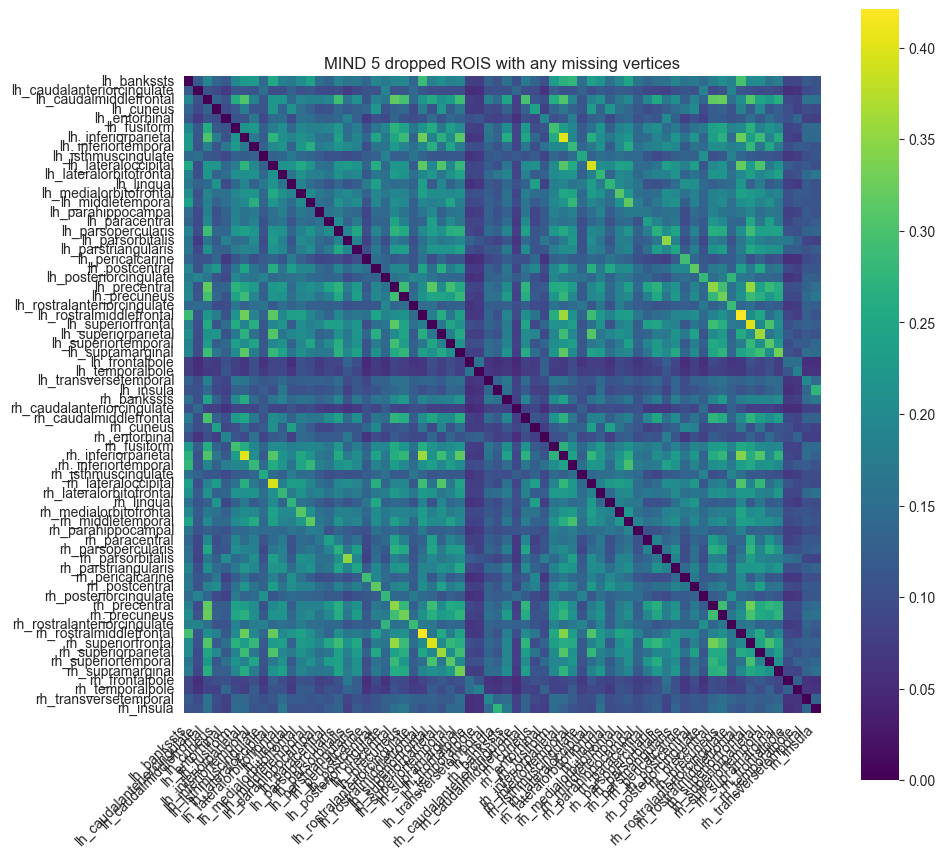

In [28]:
plt.figure(figsize=(10, 9))
labels = combined_regions  # or whatever your row labels are
sns.heatmap(MIND_tst, xticklabels=labels, yticklabels=labels, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('MIND 5 dropped ROIS with any missing vertices')
plt.tight_layout()
plt.show()

DWI DATA

In [29]:
# Path to FreeSurfer subject directory (needed for parcellation .annot files)
path_to_surf_dir = surf_dir

# Path to the vol2surf_DWI surface outputs for this subject
vol2surf_dir = os.path.join(DATA_DIR, "mystery_man", "surfaces", "vol2surf_DWI", "surface")
tmp_dir = os.path.join(MAIN_DIR, 'tmp_mgz', 'mystery_man')

# DWI metrics available in vol2surf_DWI/surface/
features = {
    'FA':    'dti_FA_T1space_al2std60_back2sub',
    'MD':    'dti_MD_T1space_al2std60_back2sub',
    'ICVF':  'NODDI_ICVF_T1space_al2std60_back2sub',
    'ISOVF': 'NODDI_ISOVF_T1space_al2std60_back2sub',
    'OD':    'NODDI_OD_T1space_al2std60_back2sub',
}

feature_tuples = convert_to_mgz(tmp_dir,
                                vol2surf_dir,
                                path_to_surf_dir,
                                parcellation,
                                features)


  FA: ready
  MD: ready
  ICVF: ready
  ISOVF: ready
  OD: ready

Using 5 DWI features: ['FA', 'MD', 'ICVF', 'ISOVF', 'OD']
Found parcellation .annot files in /Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/label


In [30]:
dti_vertex_data, dti_combined_regions, dti_used_features = get_vertex_df(path_to_surf_dir, feature_tuples, parcellation)

lh
Loading left hemisphere data:
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.FA.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.MD.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.ICVF.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.ISOVF.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.OD.mgz
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
rh
Loading right hemisphere data:
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
features used: 
['Fea

In [31]:
dti_vertex_data_n = dti_vertex_data.rename(columns={'Feature_0': "FA",
                                          'Feature_1': "MD",
                                          'Feature_2': "NDI",
                                          'Feature_3': "ISOVF",
                                          'Feature_4': "OD"})

In [32]:
# Assuming row order matches within each id
vertex_data_n = pd.concat([t1_vertex_data_n.reset_index(drop=True),
                    dti_vertex_data_n.drop(columns='Label').reset_index(drop=True)],
                   axis=1)

In [33]:
features_final = list(vertex_data_n.columns[1:])

In [34]:
# keep only 'good regions' (i.e. drop lh_??
# note that this is a step already performed when computing MIND networks, however for the purposes of all the sanity checking in the notebook
# we will add it in here
vertex_data_n = vertex_data_n[vertex_data_n['Label'].isin(combined_regions)].reset_index(drop=True)

## Clean up and scale data

Sanity check whether ISOVF should be filtered out. If ROIs with ISOVF == 0 are full for other regions unlikely.

NB. I orginally filtered by ISOVF, along with the rest of the metrics listed below and noticed that while FA,MD,NDI and OD were all 0 vertex values for two ROIs (left and right, H + STSva), ISOVF gave 0 values across 65 regions.

This raised my suspicions and based on ISOVF measuring free water volume, it may be possible that true values are indeed 0 (or intrpreted as such from freesurfer).

In [35]:
# Vertices where ISOVF is 0 but other metrics aren't
isovf_zero = vertex_data_n['ISOVF'] == 0
other_valid = (vertex_data_n[['FA', 'MD', 'NDI', 'OD']] != 0).all(axis=1)

real_low_isovf = isovf_zero & other_valid
missing_data_isovf = isovf_zero & ~other_valid

print(f"ISOVF zeros that are potential low values and not bad data: {real_low_isovf.sum()}")
print(f"ISOVF zeros that are missing/bad data: {missing_data_isovf.sum()}")

# Breakdown by region
real_low_by_region = vertex_data_n.loc[real_low_isovf, 'Label'].value_counts()
missing_by_region = vertex_data_n.loc[missing_data_isovf, 'Label'].value_counts()

print(f"\n--- ISOVF zeros = low values, by ROI ({len(real_low_by_region)} regions) ---")
print(real_low_by_region)

print(f"\n--- ISOVF zeros = missing/bad data, by ROI ({len(missing_by_region)} regions) ---")
print(missing_by_region)

ISOVF zeros that are potential low values and not bad data: 1029
ISOVF zeros that are missing/bad data: 36

--- ISOVF zeros = low values, by ROI (30 regions) ---
Label
rh_middletemporal              154
rh_caudalanteriorcingulate     149
lh_middletemporal              116
rh_inferiorparietal            107
lh_rostralmiddlefrontal         61
rh_inferiortemporal             46
rh_rostralanteriorcingulate     43
rh_medialorbitofrontal          42
rh_parahippocampal              42
lh_medialorbitofrontal          36
rh_superiorfrontal              32
rh_rostralmiddlefrontal         22
rh_posteriorcingulate           20
lh_parsopercularis              20
rh_fusiform                     20
lh_fusiform                     16
lh_inferiortemporal             14
lh_superiortemporal             14
lh_bankssts                     13
lh_rostralanteriorcingulate     13
rh_lingual                      12
lh_superiorfrontal              11
rh_lateralorbitofrontal          6
rh_bankssts                

In [36]:
# RUN QC
vertex_data_clean, n_removed_vertices, per_label_stats = filter_vertex_data(vertex_data_n,
                                                           features_final,
                                                           features_final,
                                                           features2filter = ('CT', 'Vol', 'SA', 'FA', 'MD', 'NDI', 'OD'),
                                                           verbose=True)
print(f"Cleaned data and removed {n_removed_vertices} vertices.")

VERTEX DATA CLEAN UP LOGGING
=== Features list being used and final conversion dictionaries ===
features:       ['CT', 'MC', 'Vol', 'SD', 'SA', 'FA', 'MD', 'NDI', 'ISOVF', 'OD']
used_features:  ['CT', 'MC', 'Vol', 'SD', 'SA', 'FA', 'MD', 'NDI', 'ISOVF', 'OD']
conv_dict:      {'CT': 'CT', 'MC': 'MC', 'Vol': 'Vol', 'SD': 'SD', 'SA': 'SA', 'FA': 'FA', 'MD': 'MD', 'NDI': 'NDI', 'ISOVF': 'ISOVF', 'OD': 'OD'}
=== Inspect orginal data compared to cleaned up data ===
Before filtering: 237778 rows
After filtering:  237674 rows
Removed:          104 rows
CT (CT): 30 zeros before filtering
Vol (Vol): 59 zeros before filtering
SA (SA): 0 zeros before filtering
FA (FA): 36 zeros before filtering
MD (MD): 36 zeros before filtering
NDI (NDI): 36 zeros before filtering
OD (OD): 36 zeros before filtering
CT (CT): 0 zeros remaining
Vol (Vol): 0 zeros remaining
SA (SA): 0 zeros remaining
FA (FA): 0 zeros remaining
MD (MD): 0 zeros remaining
NDI (NDI): 0 zeros remaining
OD (OD): 0 zeros remaining
=== Chec

In [37]:
# scale non clean data
vertex_data_z = scale_vertex_data(vertex_data_n)

# scale clean data
vertex_data_clean_z = scale_vertex_data(vertex_data_clean)

In [38]:
print(vertex_data_z.shape)
print(vertex_data_z.dtypes)
print(vertex_data_z.index)
print(f"memory: {vertex_data_z.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(vertex_data_z.head(2))

(237778, 11)
Label     object
CT       float64
MC       float64
Vol      float64
SD       float64
SA       float64
FA       float64
MD       float64
NDI      float64
ISOVF    float64
OD       float64
dtype: object
RangeIndex(start=0, stop=237778, step=1)
memory: 36.7 MB
                 Label        CT        MC       Vol        SD        SA  \
0  lh_lateraloccipital -0.169153 -1.947843 -1.323803 -0.862577 -1.951950   
1  lh_lateraloccipital -0.211702 -1.911744 -1.090086 -0.806025 -1.814181   

         FA       MD       NDI     ISOVF        OD  
0  4.143830 -0.57533  0.935824 -0.147813 -1.004759  
1  4.405714 -0.57533  0.974503 -0.285198 -0.999040  


In [39]:
mind = calculate_mind_network_fast(vertex_data_z,
                                   features_final,
                                   combined_regions,
                                   per_label_stats["pct_retained"],
                                   pct_threshold=95,
                                   min_vertices=1,
                                   verbose=True)

✓ regions matches region_list exactly (same items, same order)
Computing 2278 region pairs across 8 cores (skipping 0 pairs involving undersized regions)...


Check of ROIs with no or small n vertices post data cleaning

In [40]:
mind_clean = calculate_mind_network_fast(vertex_data_clean_z,
                                         features_final,
                                           combined_regions,
                                           per_label_stats["pct_retained"],
                                           pct_threshold=95,
                                           min_vertices=1,
                                           verbose=True)

✓ regions matches region_list exactly (same items, same order)
Computing 2278 region pairs across 8 cores (skipping 0 pairs involving undersized regions)...


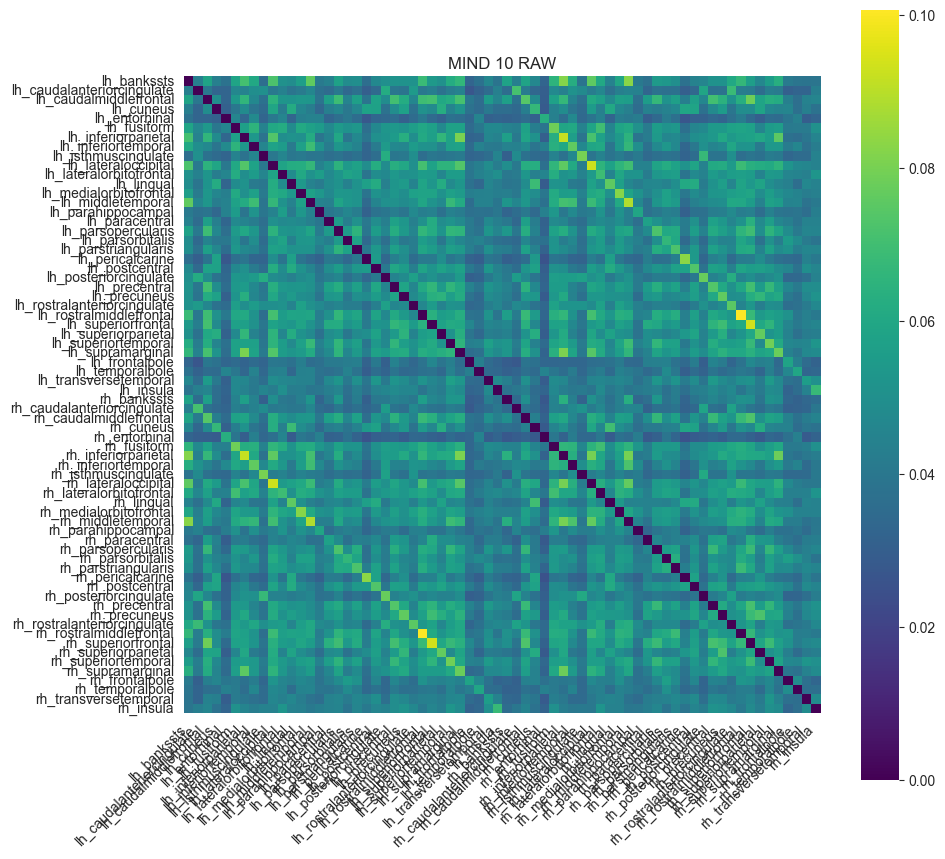

In [41]:
plt.figure(figsize=(10, 9))
labels = combined_regions  # or whatever your row labels are
sns.heatmap(mind, xticklabels=labels, yticklabels=labels, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('MIND 10 RAW')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, f"{parcellation}_mind_10_RAW.png"))
plt.show()

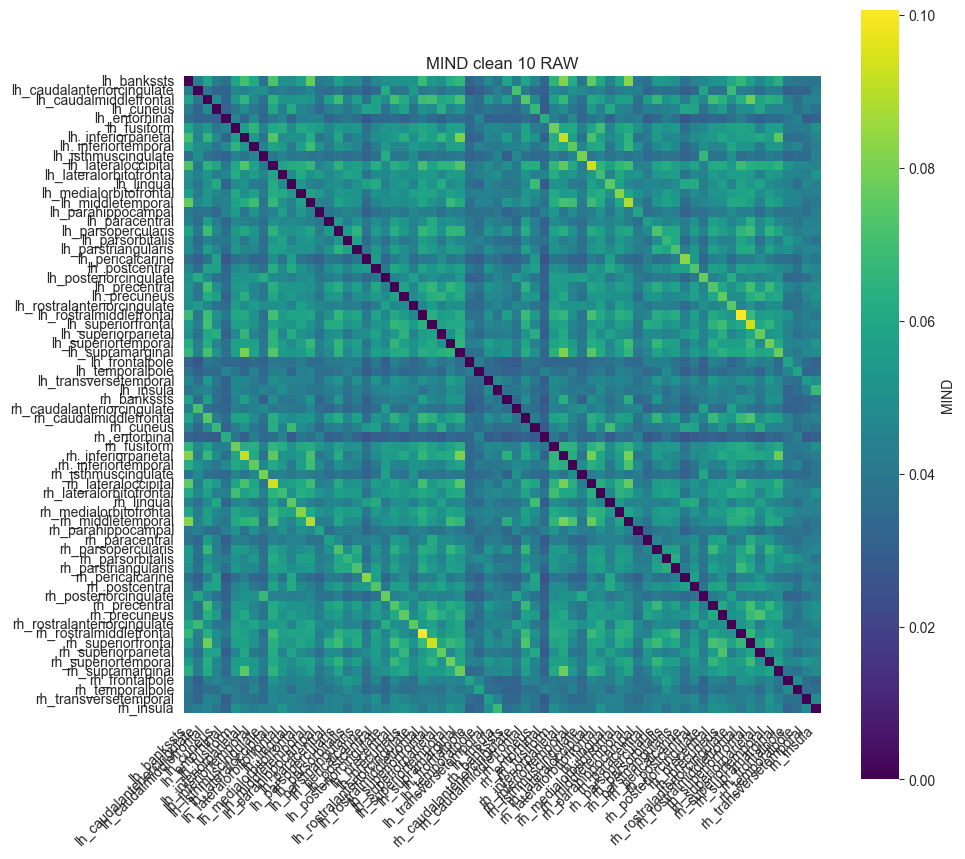

In [42]:
plt.figure(figsize=(10, 9))
labels = combined_regions

# Use a copy of viridis with NaN cells shown in grey
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='lightgrey')

sns.heatmap(
    mind_clean,
    xticklabels=labels,
    yticklabels=labels,
    cmap=cmap,
    square=True,
    mask=mind.isna(),       # tells seaborn to skip NaN cells
    cbar_kws={'label': 'MIND'},
)

# Optional: grey out the row/column labels for undersized regions
ax = plt.gca()
all_nan_rows = mind_clean.isna().all(axis=1)
for tick, region in zip(ax.get_yticklabels(), labels):
    if all_nan_rows.get(region, False):
        tick.set_color('lightgrey')
for tick, region in zip(ax.get_xticklabels(), labels):
    if all_nan_rows.get(region, False):
        tick.set_color('lightgrey')

plt.xticks(rotation=45, ha='right')
plt.title('MIND clean 10 RAW')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, f"{parcellation}_mind_clean_10_RAW.png"))
plt.show()

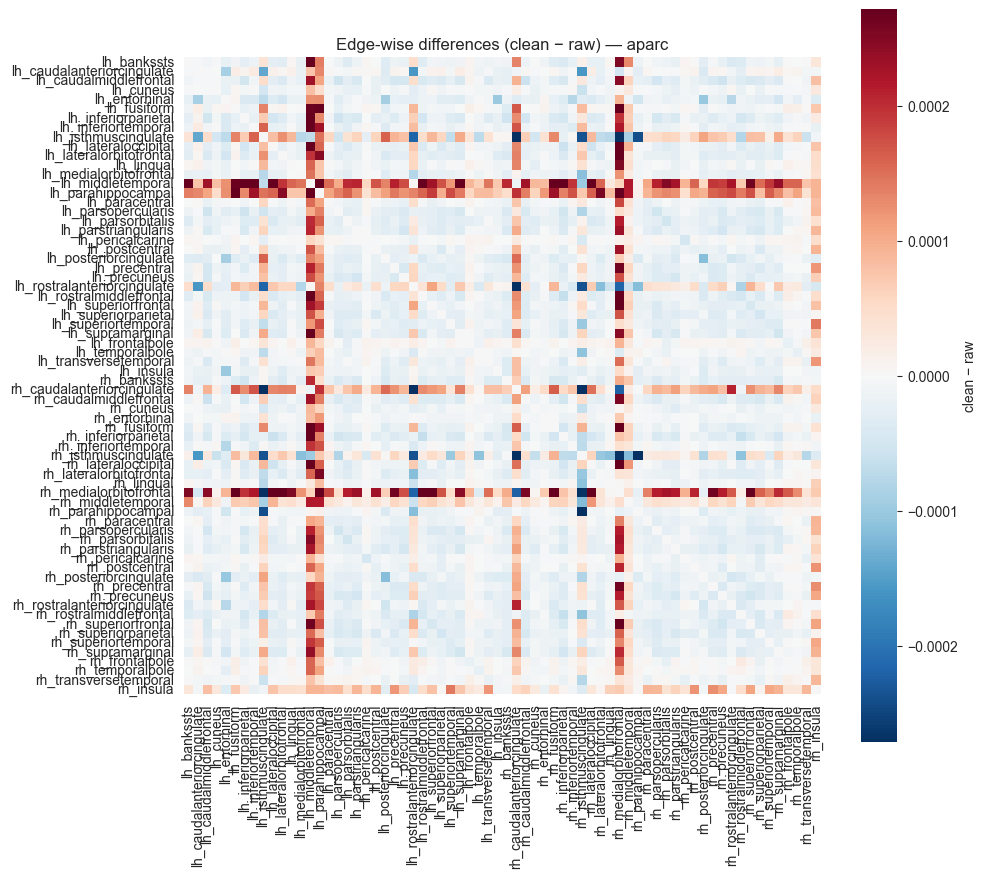

In [43]:
labels = combined_regions
# reconstruct full difference matrix
# negative values mean that the PCA mind resulted in higher (stronger) edge-wise connections
diff_matrix = mind_clean.values - mind.values  # signed differences, NaNs preserved

# Symmetric color limits centered on zero so the diverging cmap is meaningful
vmax = np.nanpercentile(np.abs(diff_matrix), 99)
vmin = -vmax

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    diff_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=vmin,
    vmax=vmax,
    square=True,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"label": "clean − raw"},
    ax=ax,
)
ax.set_title(f"Edge-wise differences (clean − raw) — {parcellation}")
plt.tight_layout()

# Save and show
diff_path = os.path.join(PLOT_DIR, f"{parcellation}_mindclean2raw_diff_heatmap.png")
plt.savefig(diff_path, dpi=200, bbox_inches="tight")
plt.show()
#print(f"Saved heatmap to {diff_path}")

Check agreement between cleaned up and raw MIND networks

In [44]:
# --- Configure which features to check for zeros ---
zero_check_features = ['CT', 'Vol', 'SA']  + ['FA', 'MD', 'NDI', 'ODI']

# --- Per-feature zero diagnostics ---
zero_stats = {}
for feat in zero_check_features:
    if feat not in vertex_data_n.columns:
        continue
    mask = vertex_data_n[feat] == 0
    by_region = vertex_data_n[mask]['Label'].value_counts()
    zero_stats[feat] = {
        'total': int(mask.sum()),
        'n_regions': int((by_region > 0).sum()),
        'top': by_region.head(20),
    }

# --- Region-size diagnostics (reused for raw and clean) ---
def region_diagnostics(df, combined_regions, min_n=n_minimum, head_n=100):
    sizes = df.groupby('Label').size()
    return {
        'head': sizes.sort_values().head(head_n),
        'missing': set(combined_regions) - set(sizes.index),
        'below_min': sizes[sizes < min_n].to_dict(),
    }

raw_diag = region_diagnostics(vertex_data_z, combined_regions)
clean_diag = region_diagnostics(vertex_data_clean_z, combined_regions)

# --- Edge-level comparison (upper triangle, exclude diagonal) ---
iu = np.triu_indices_from(mind_clean.values, k=1)
raw_edges = mind.values[iu]
nan_edges = mind_clean.values[iu]
valid = ~np.isnan(nan_edges)

r, p = pearsonr(raw_edges[valid], nan_edges[valid])
rho, _ = spearmanr(raw_edges[valid], nan_edges[valid])
diff = raw_edges[valid] - nan_edges[valid]

# --- Build output string ---
lines = ["NB: Nuisance regions (e.g. lh_???) are removed during MIND computation (NOT PRESENT IN FINAL ANALYSIS!).", ""]

lines.append("=== Zero-value vertex counts ===")
for feat, stats_ in zero_stats.items():
    lines.append(f"\n[{feat}] total zero vertices: {stats_['total']}, spread across {stats_['n_regions']} regions")
    lines.append(str(stats_['top']))

lines.append("\n=== Raw MIND region sizes ===")
lines.append(f"First 100 ROIs (smallest first):\n{raw_diag['head']}")
lines.append(f"\nRegions missing from raw MIND: {raw_diag['missing']}")
lines.append(f"Regions in raw MIND with <{n_minimum} vertices: {raw_diag['below_min']}")

lines.append("\n=== Clean MIND region sizes ===")
lines.append(f"First 100 ROIs (smallest first):\n{clean_diag['head']}")
lines.append(f"\nRegions missing from clean MIND: {clean_diag['missing']}")
lines.append(f"Regions in clean MIND with <{n_minimum} vertices: {clean_diag['below_min']}")

lines.append("\n=== Edge-level comparison (raw vs clean) ===")
lines.append(f"Comparing {valid.sum()} of {len(nan_edges)} edges ({100*valid.mean():.1f}%)")
lines.append(f"Pearson r  = {r:.4f}, p = {p:.2e}")
lines.append(f"Spearman ρ = {rho:.4f}")
lines.append(f"Mean difference: {diff.mean():.4f}")
lines.append(f"95% limits: [{diff.mean() - 1.96*diff.std():.4f}, {diff.mean() + 1.96*diff.std():.4f}]")

output = "\n".join(lines)

# Print + save
print(output)

out_path = os.path.join(PLOT_DIR, f"{parcellation}_mind_comparison_stats.txt")
with open(out_path, "w") as f:
    f.write(output + "\n")

#print(f"\nSaved to {out_path}")

NB: Nuisance regions (e.g. lh_???) are removed during MIND computation (NOT PRESENT IN FINAL ANALYSIS!).

=== Zero-value vertex counts ===

[CT] total zero vertices: 30, spread across 9 regions
Label
lh_isthmuscingulate            7
rh_isthmuscingulate            7
rh_medialorbitofrontal         7
lh_rostralanteriorcingulate    3
lh_fusiform                    2
lh_posteriorcingulate          1
lh_insula                      1
rh_posteriorcingulate          1
rh_fusiform                    1
Name: count, dtype: int64

[Vol] total zero vertices: 59, spread across 6 regions
Label
rh_insula                 27
rh_medialorbitofrontal    11
lh_parahippocampal         9
lh_isthmuscingulate        7
lh_insula                  3
lh_entorhinal              2
Name: count, dtype: int64

[SA] total zero vertices: 0, spread across 0 regions
Series([], Name: count, dtype: int64)

[FA] total zero vertices: 36, spread across 8 regions
Label
lh_middletemporal              11
rh_medialorbitofrontal      

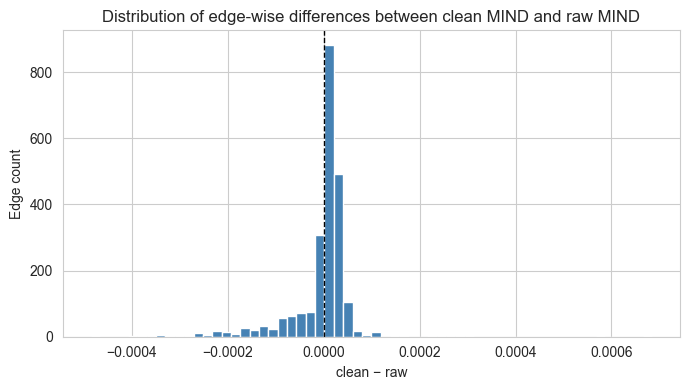

In [45]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(diff[~np.isnan(diff)], bins=60, color="steelblue", edgecolor="white")
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_xlabel("clean − raw")
ax.set_ylabel("Edge count")
ax.set_title(f"Distribution of edge-wise differences between clean MIND and raw MIND")
plt.tight_layout()
diff_hist_path = os.path.join(PLOT_DIR, f"{parcellation}_differences_clean2raw__distribution.png")
plt.savefig(diff_hist_path, dpi=200, bbox_inches="tight")
plt.show()

          CT      MC      Vol       SD      SA      FA      MD     NDI  \
min   0.1993 -1.2854   0.0101 -13.8752  0.0146  0.0009  0.0000  0.0042   
max   5.0000  0.7056  22.2162  17.4334  4.6570  0.6100  0.0025  0.9402   
mean  2.7965 -0.0398   2.0501  -0.0213  0.6646  0.1087  0.0010  0.3642   
std   0.6870  0.1800   1.3852   5.3774  0.3111  0.0374  0.0002  0.0488   

       ISOVF      OD  
min   0.0000  0.0064  
max   0.9849  0.8464  
mean  0.1694  0.5516  
std   0.1506  0.0694  


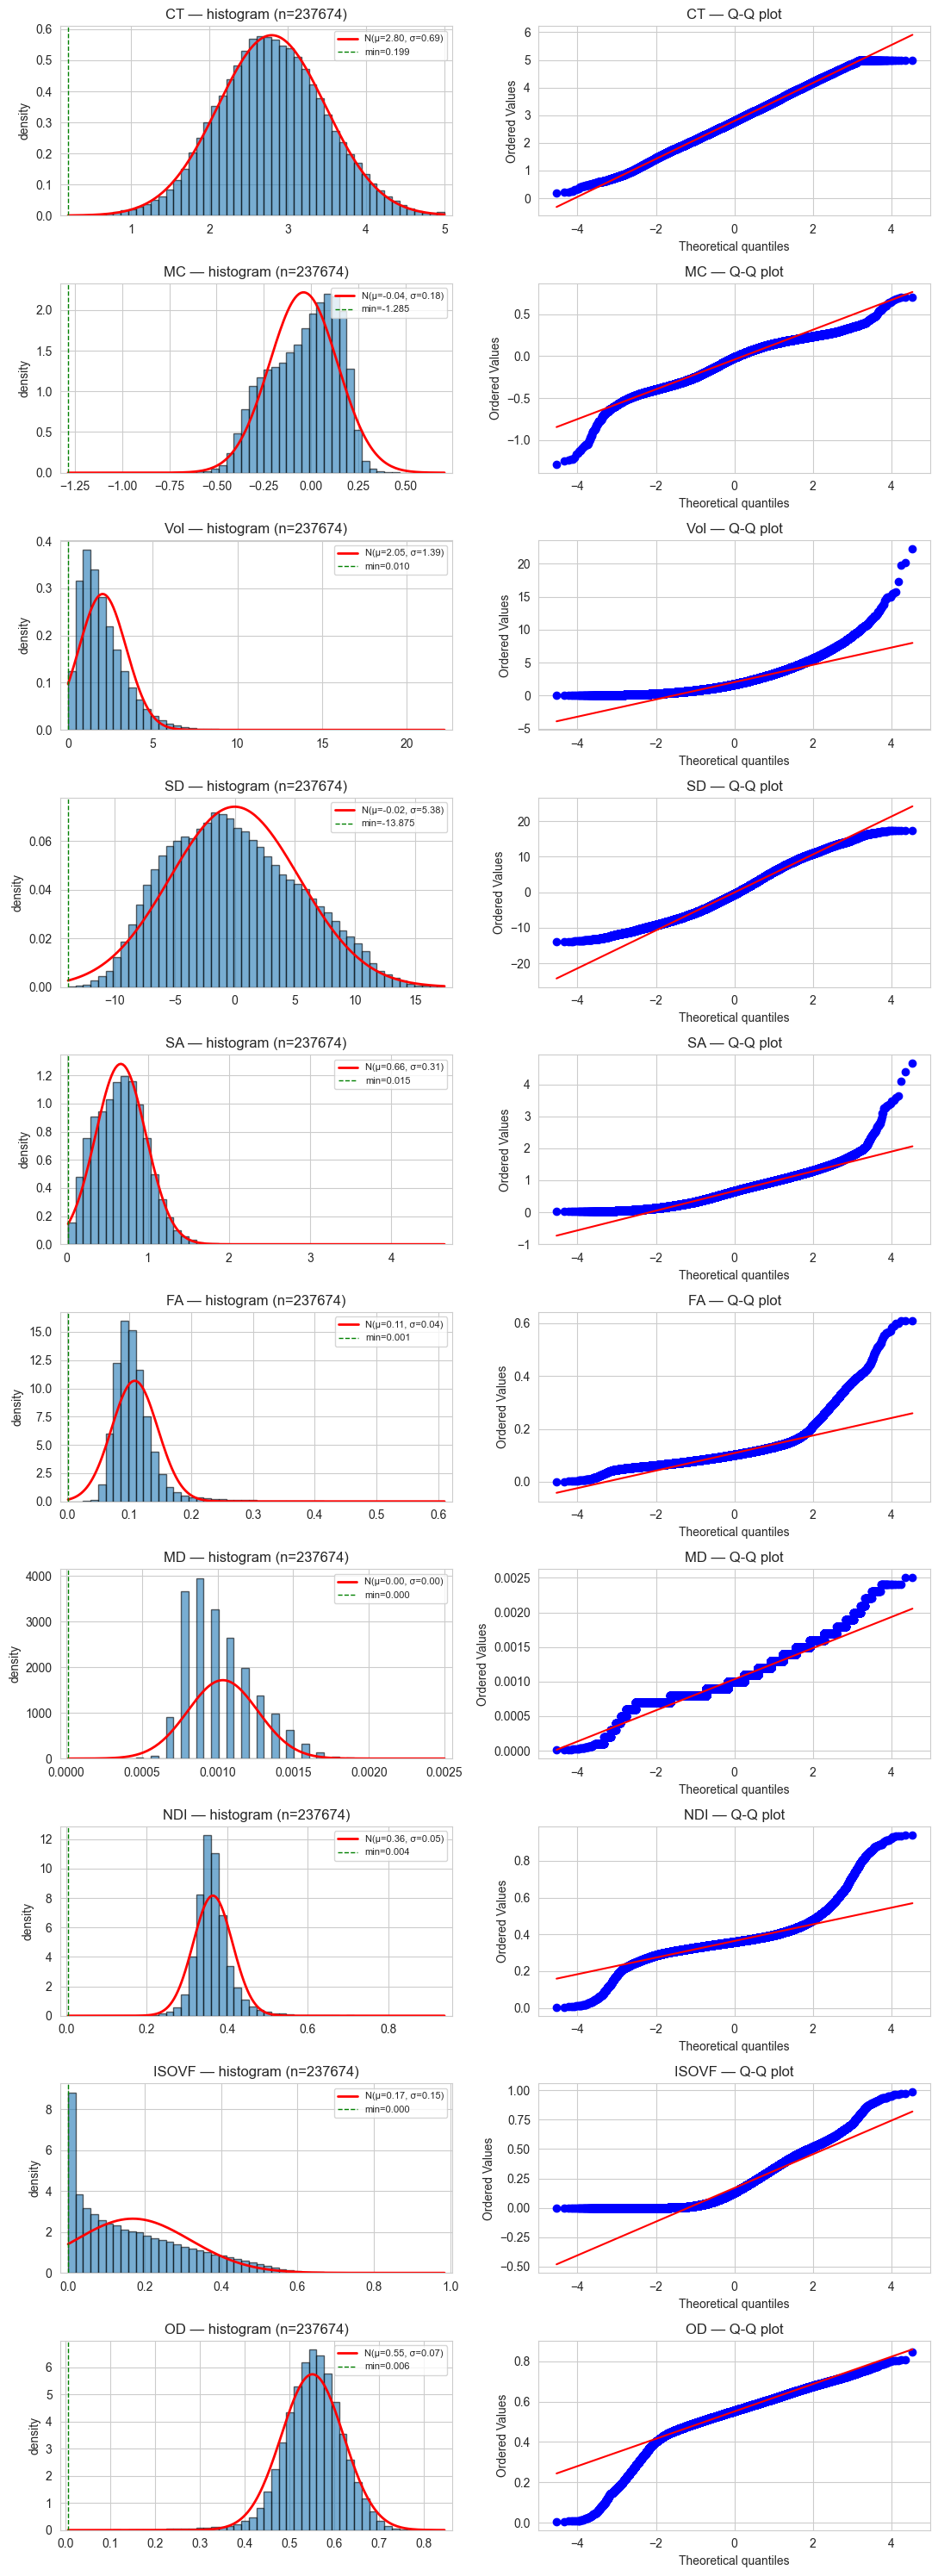

In [46]:
features = vertex_data_clean.iloc[:, 1:]
cols = features.columns
n = len(cols)

print(features.describe().loc[['min', 'max', 'mean', 'std']].round(4))

fig, axes = plt.subplots(n, 2, figsize=(11, 3 * n))

for i, col in enumerate(cols):
    data = features[col].dropna()

    # --- Histogram ---
    ax_hist = axes[i, 0]
    ax_hist.hist(data, bins=50, density=True, alpha=0.6, edgecolor='black')

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax_hist.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2,
                 label=f'N(μ={mu:.2f}, σ={sigma:.2f})')

    # Mark the actual minimum so you can confirm it's > 0
    ax_hist.axvline(data.min(), color='green', linestyle='--', lw=1,
                    label=f'min={data.min():.3f}')

    # Tight x-axis around the actual data range
    pad = (data.max() - data.min()) * 0.02
    ax_hist.set_xlim(data.min() - pad, data.max() + pad)

    ax_hist.set_title(f'{col} — histogram (n={len(data)})')
    ax_hist.set_ylabel('density')
    ax_hist.legend(fontsize=8, loc='upper right')

    # --- Q-Q plot ---
    ax_qq = axes[i, 1]
    stats.probplot(data, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'{col} — Q-Q plot')

plt.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, f'{parcellation}_features_normality.png'),
            dpi=120, bbox_inches='tight')
plt.show()

In [47]:
final_roi_list = np.array(vertex_data_n.iloc[:,0]) # list of ROIs
id_col   = vertex_data_n.columns[0] # name of the ROI column (Label)
features = vertex_data_n.columns[1:] # final set of features used

In [48]:
roi_counts = vertex_data_n.groupby('Label').size()
print(roi_counts)

Label
lh_bankssts                   1441
lh_caudalanteriorcingulate     898
lh_caudalmiddlefrontal        3504
lh_cuneus                     2009
lh_entorhinal                  776
                              ... 
rh_superiorparietal           7114
rh_superiortemporal           5158
rh_supramarginal              5076
rh_temporalpole                767
rh_transversetemporal          582
Length: 68, dtype: int64
